In [2]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from msfm.utils import catalog, lensing, files

In [3]:
repo_dir = os.path.abspath("../../..")
conf_path = os.path.join(repo_dir, "configs/v16/default.yaml")
conf = files.load_config(conf_path)

n_side = conf["analysis"]["n_side"]
n_pix = hp.nside2npix(n_side)
l_max = 3 * n_side - 1

survey_mask = np.array([1.0] * n_pix)
# survey_mask = files.get_mask(conf, nest_out=False)

In [4]:
wl_gamma_map, _ = catalog.build_full_metacal_map_from_cat(conf)
# wl_gamma_map: (n_pix, 2) -- full non-tomographic shear map in RING ordering

26-05-14 10:02:55   catalog.py INF   Loaded full metacal maps from cache 


In [5]:
_, gamma2kappa_fac, _ = lensing.get_kaiser_squires_factors(l_max)

g1 = wl_gamma_map[:, 0] * survey_mask
g2 = wl_gamma_map[:, 1] * survey_mask

_, alm_E, alm_B = hp.map2alm(
    [np.zeros_like(g1), g1, g2], pol=True, use_pixel_weights=True
)
kappa_E = hp.alm2map(alm_E * gamma2kappa_fac, n_side, pol=False)
kappa_B = hp.alm2map(alm_B * gamma2kappa_fac, n_side, pol=False)

print(f"sigma(E) = {kappa_E[survey_mask > 0].std():.4e}")
print(f"sigma(B) = {kappa_B[survey_mask > 0].std():.4e}")

sigma(E) = 7.2936e-03
sigma(B) = 7.2898e-03


In [6]:
sigma_rad = np.radians(10 / 60)  # 10 arcmin

def smooth_masked(map_in, mask):
    """Zero empty/out-of-footprint pixels before SH smoothing to avoid contamination,
    then restore them as UNSEEN. Caller can pre-set empty pixels to hp.UNSEEN."""
    m = map_in.copy().astype(float)
    empty = (m == hp.UNSEEN) | ~mask.astype(bool)
    m[empty] = 0.0
    m = hp.smoothing(m, sigma=sigma_rad)
    m[empty] = hp.UNSEEN
    return m


# catalog.py applies _get_rot_z(z_rad) @ _get_rot_y(y_rad) to sky vectors, where each
# helper returns the standard rotation matrix transposed (= inverse rotation).
# Forward transform: R_cat = R_z(-z_rad) @ R_y(-y_rad)
# Pull mapping undoes this: output[p_sky] = input[pix(R_cat @ vec(p_sky))]
def _std_rot_y(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])

def _std_rot_z(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

y_rad = conf["analysis"]["footprint"]["rotation"]["y_rad"]
z_rad = conf["analysis"]["footprint"]["rotation"]["z_rad"]
R_cat = _std_rot_z(-z_rad) @ _std_rot_y(-y_rad)

def rotate_map_nn(m, R):
    """Nearest-neighbor pixel remap: output[p] = input[pix(R @ vec(p))]."""
    theta, phi = hp.pix2ang(n_side, np.arange(n_pix))
    vecs = hp.ang2vec(theta, phi)  # (n_pix, 3)
    vecs_rot = R @ vecs.T          # (3, n_pix)
    ipix_src = hp.vec2pix(n_side, vecs_rot[0], vecs_rot[1], vecs_rot[2])
    return m[ipix_src]

26-05-14 10:02:55   catalog.py INF   Loaded full metacal maps from cache 


26-05-14 10:02:56   catalog.py INF   Loaded full metacal maps from cache 
26-05-14 10:02:57   catalog.py INF   Loaded full metacal maps from cache 
26-05-14 10:02:58   catalog.py INF   Loaded full metacal maps from cache 


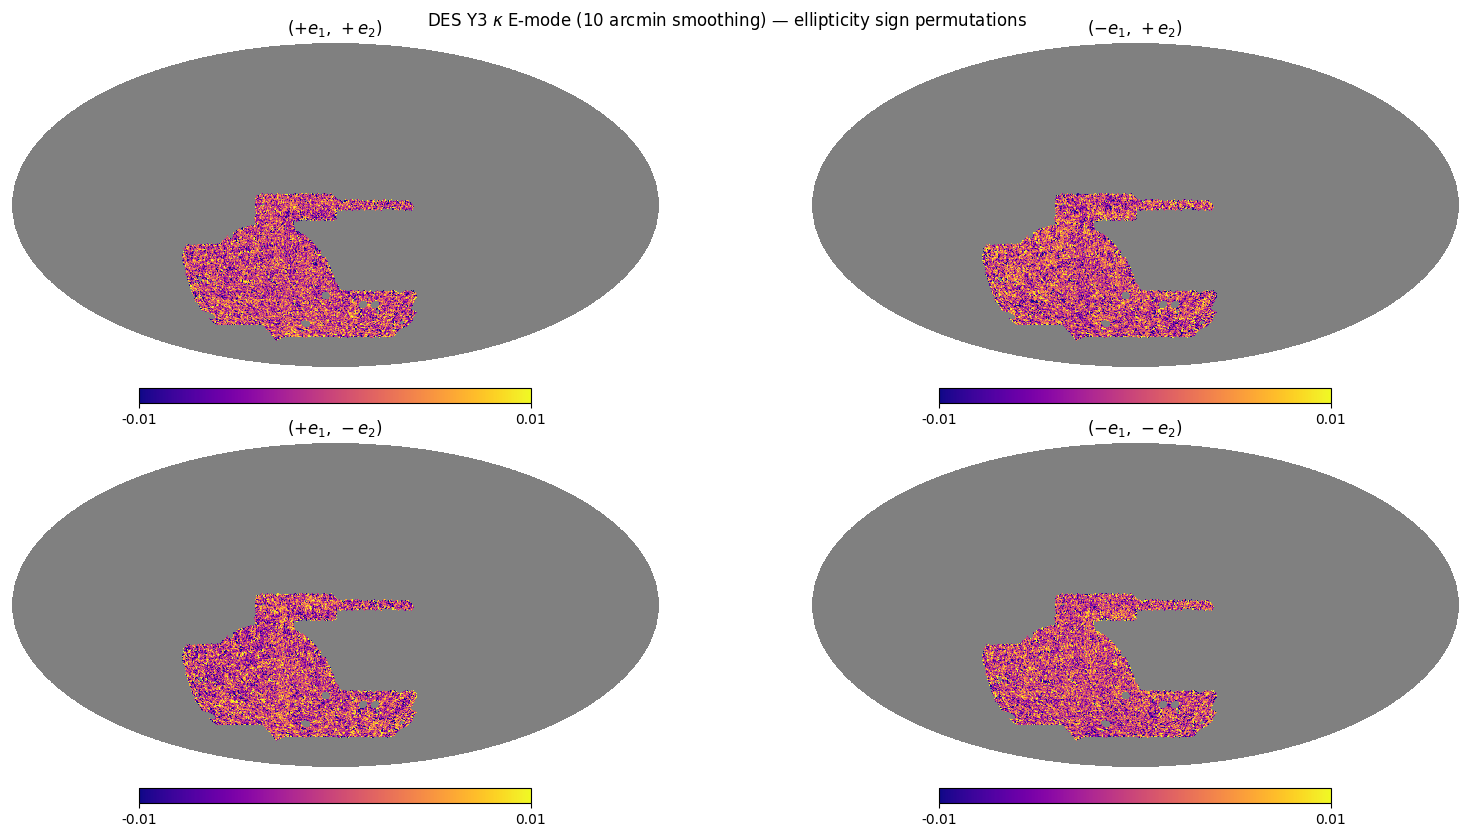

In [7]:
fig_dir = os.path.join(repo_dir, "dev/notebooks/desy3/figures/full_metacal")
os.makedirs(fig_dir, exist_ok=True)

sign_perms = [(1, 1), (-1, 1), (1, -1), (-1, -1)]
sign_labels = [r"$(+e_1,\,+e_2)$", r"$(-e_1,\,+e_2)$", r"$(+e_1,\,-e_2)$", r"$(-e_1,\,-e_2)$"]

kappa_E_maps = []
for sign_e1, sign_e2 in sign_perms:
    gmap, count_map = catalog.build_full_metacal_map_from_cat(conf, sign_e1=sign_e1, sign_e2=sign_e2)
    g1 = gmap[:, 0] * survey_mask
    g2 = gmap[:, 1] * survey_mask
    _, alm_E, _ = hp.map2alm([np.zeros_like(g1), g1, g2], pol=True, use_pixel_weights=True)
    kappa_E = hp.alm2map(alm_E * gamma2kappa_fac, n_side, pol=False)
    kappa_E[count_map == 0] = hp.UNSEEN  # mark empty pixels before smoothing
    kappa_E_sky = rotate_map_nn(smooth_masked(kappa_E, survey_mask), R_cat)
    kappa_E_maps.append(kappa_E_sky)

# figsize: 2 cols × 8 inches, 2 rows × 4 inches → each subplot is 8×4 (2:1),
# matching mollview's native aspect ratio so no horizontal padding is added inside panels.
fig = plt.figure(figsize=(16, 8))
for i, (m, label) in enumerate(zip(kappa_E_maps, sign_labels)):
    hp.mollview(m, title=label, fig=fig.number, sub=(2, 2, i + 1), notext=True, xsize=3000, cmap="plasma", min=-0.01, max=0.01)
plt.subplots_adjust(wspace=0, hspace=0.1)
plt.suptitle(r"DES Y3 $\kappa$ E-mode (10 arcmin smoothing) — ellipticity sign permutations", y=1.02)
plt.savefig(os.path.join(fig_dir, "des_y3_kappa_sign_perms.png"), dpi=150, bbox_inches="tight")
plt.show()

26-05-14 10:03:04   catalog.py INF   Loaded full metacal maps from cache 
26-05-14 10:03:04   catalog.py INF   Loaded full metacal maps from cache 
26-05-14 10:03:05   catalog.py INF   Loaded full metacal maps from cache 
26-05-14 10:03:05   catalog.py INF   Loaded full metacal maps from cache 


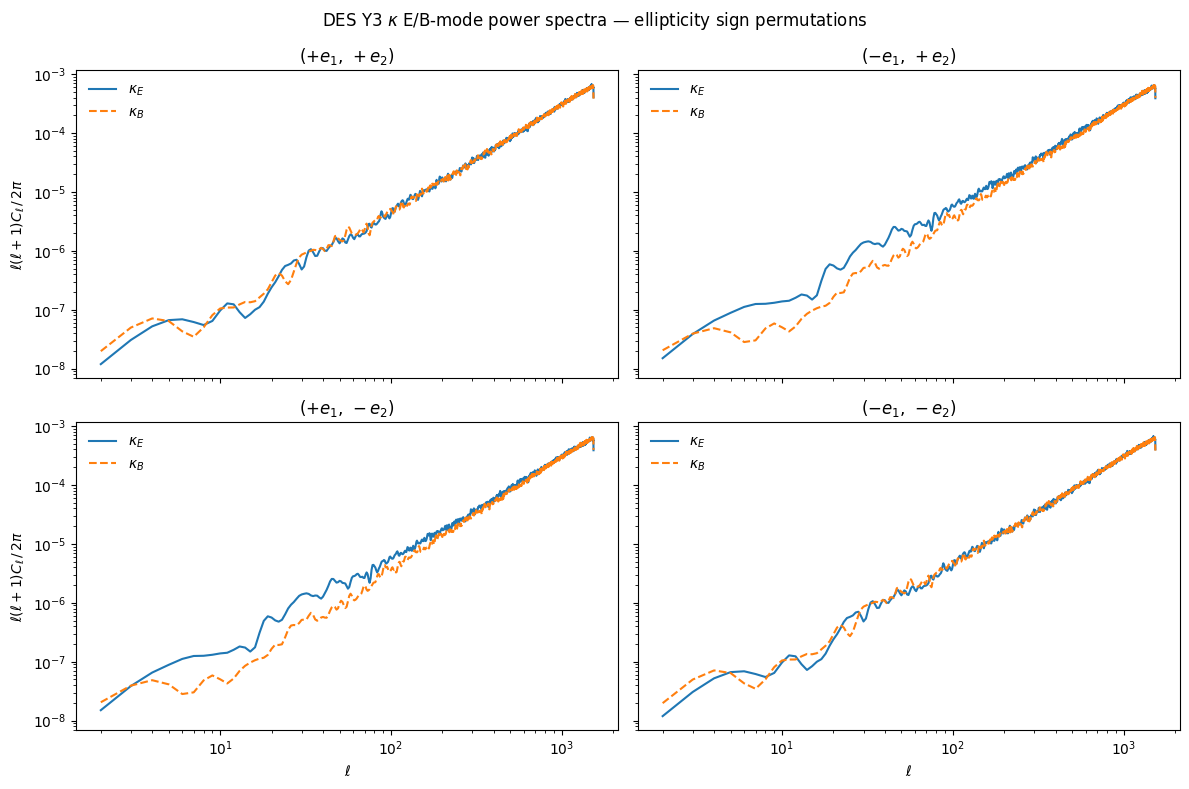

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (sign_e1, sign_e2) in enumerate(sign_perms):
    gmap, count_map = catalog.build_full_metacal_map_from_cat(conf, sign_e1=sign_e1, sign_e2=sign_e2)
    g1 = gmap[:, 0] * survey_mask
    g2 = gmap[:, 1] * survey_mask
    _, alm_E, alm_B = hp.map2alm([np.zeros_like(g1), g1, g2], pol=True, use_pixel_weights=True)
    kappa_E = hp.alm2map(alm_E * gamma2kappa_fac, n_side, pol=False)
    kappa_B = hp.alm2map(alm_B * gamma2kappa_fac, n_side, pol=False)

    # zero pixels with no galaxies; apply fsky correction for partial sky
    no_gal = ~((count_map > 0) & survey_mask.astype(bool))
    kappa_E[no_gal] = 0.0
    kappa_B[no_gal] = 0.0
    fsky = 1.0 - no_gal.mean()

    cl_E = hp.anafast(kappa_E, lmax=l_max) / fsky
    cl_B = hp.anafast(kappa_B, lmax=l_max) / fsky
    ell = np.arange(len(cl_E))
    fac = ell * (ell + 1) / (2 * np.pi)

    ax = axes[idx]
    ax.loglog(ell[2:], (fac * cl_E)[2:], label=r"$\kappa_E$")
    ax.loglog(ell[2:], (fac * cl_B)[2:], label=r"$\kappa_B$", ls="--")
    ax.set_title(sign_labels[idx])
    ax.legend(frameon=False)

for ax in axes[2:]:
    ax.set_xlabel(r"$\ell$")
for ax in axes[::2]:
    ax.set_ylabel(r"$\ell(\ell+1)C_\ell\,/\,2\pi$")

fig.suptitle(r"DES Y3 $\kappa$ E/B-mode power spectra — ellipticity sign permutations")
fig.tight_layout()
plt.savefig(os.path.join(fig_dir, "des_y3_kappa_cls_sign_perms.png"), dpi=150, bbox_inches="tight")
plt.show()